In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


1. LOAD DATA

In [2]:
df = pd.read_csv("TRAIN.csv")
df1 = pd.read_csv("TEST.csv")

2. DATA PREPARATION

In [3]:
# Handle missing values
df = df.fillna(df.mean(numeric_only=True))
df1 = df1.fillna(df1.mean(numeric_only=True))

# Remove duplicates
df = df.drop_duplicates()

# Convert datetime
df['Data'] = pd.to_datetime(df['Data'])
df1['Data'] = pd.to_datetime(df1['Data'])

df['Time'] = pd.to_datetime(df['Time'])
df['RiseTime'] = pd.to_datetime(df['RiseTime'])
df['SetTime'] = pd.to_datetime(df['SetTime'])

df1['Time'] = pd.to_datetime(df1['Time'])
df1['RiseTime'] = pd.to_datetime(df1['RiseTime'])
df1['SetTime'] = pd.to_datetime(df1['SetTime'])

C:\Users\verma\AppData\Local\Temp\ipykernel_22216\989021999.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Data'] = pd.to_datetime(df['Data'])
C:\Users\verma\AppData\Local\Temp\ipykernel_22216\989021999.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1['Data'] = pd.to_datetime(df1['Data'])
C:\Users\verma\AppData\Local\Temp\ipykernel_22216\989021999.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])
C:\Users\verma\AppData\Local\Temp\ipykernel_22216\989021999.py:13: UserWarning: Could not infer format, so each element 

 3. FEATURE ENGINEERING

In [4]:
# Train data
df['Data_year'] = df['Data'].dt.year
df['Data_month'] = df['Data'].dt.month
df['Data_day'] = df['Data'].dt.day

df['Time_hour'] = df['Time'].dt.hour
df['Time_minute'] = df['Time'].dt.minute

df['RiseTime_hour'] = df['RiseTime'].dt.hour
df['RiseTime_minute'] = df['RiseTime'].dt.minute
df['RiseTime_second'] = df['RiseTime'].dt.second

df['SetTime_hour'] = df['SetTime'].dt.hour
df['SetTime_minute'] = df['SetTime'].dt.minute
df['SetTime_second'] = df['SetTime'].dt.second

In [5]:
# Test data
df1['Data_year'] = df1['Data'].dt.year
df1['Data_month'] = df1['Data'].dt.month
df1['Data_day'] = df1['Data'].dt.day

df1['Time_hour'] = df1['Time'].dt.hour
df1['Time_minute'] = df1['Time'].dt.minute

df1['RiseTime_hour'] = df1['RiseTime'].dt.hour
df1['RiseTime_minute'] = df1['RiseTime'].dt.minute
df1['RiseTime_second'] = df1['RiseTime'].dt.second

df1['SetTime_hour'] = df1['SetTime'].dt.hour
df1['SetTime_minute'] = df1['SetTime'].dt.minute
df1['SetTime_second'] = df1['SetTime'].dt.second


 4. DROP UNUSED COLUMNS

In [6]:
df_new = df.drop(['idx','Data','Time','SetTime','RiseTime'], axis=1)
df_new1 = df1.drop(['idx','Data','Time','SetTime','RiseTime'], axis=1)


5. DATA ANALYSIS

In [7]:
print("Dataset Info:\n", df_new.info())
print("\nStatistics:\n", df_new.describe())

print("\nAverage Heat:", df_new['Heat'].mean())


<class 'pandas.DataFrame'>
RangeIndex: 26149 entries, 0 to 26148
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   UNIXTime         26149 non-null  int64  
 1   Heat             26149 non-null  float64
 2   Temperature      26149 non-null  int64  
 3   Pressure         26149 non-null  float64
 4   Humidity         26149 non-null  int64  
 5   WindDegrees      26149 non-null  float64
 6   WindSpeed        26149 non-null  float64
 7   Data_year        26149 non-null  int32  
 8   Data_month       26149 non-null  int32  
 9   Data_day         26149 non-null  int32  
 10  Time_hour        26149 non-null  int32  
 11  Time_minute      26149 non-null  int32  
 12  RiseTime_hour    26149 non-null  int32  
 13  RiseTime_minute  26149 non-null  int32  
 14  RiseTime_second  26149 non-null  int32  
 15  SetTime_hour     26149 non-null  int32  
 16  SetTime_minute   26149 non-null  int32  
 17  SetTime_second   26149 

6. VISUALIZATION

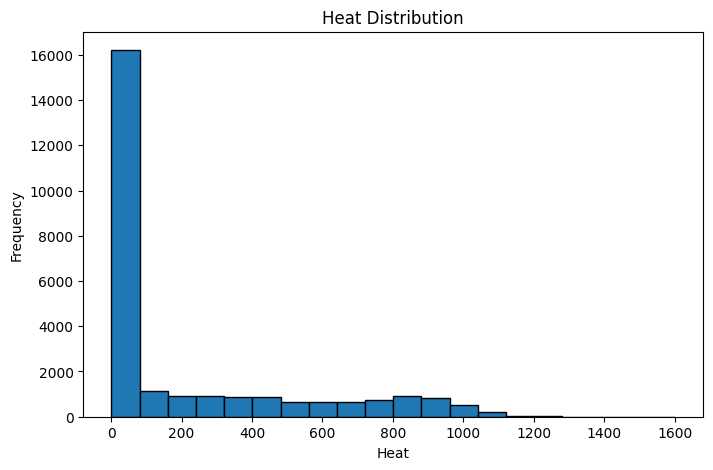

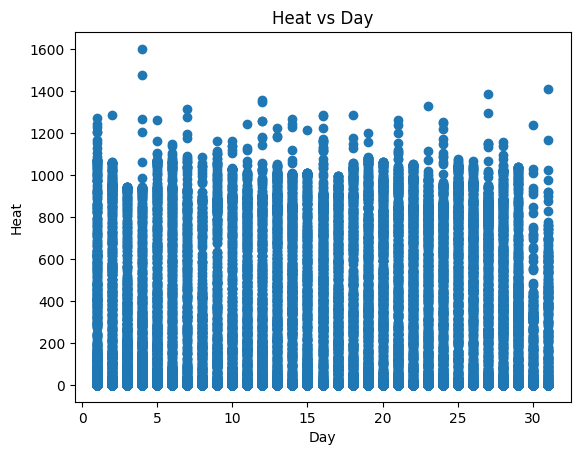

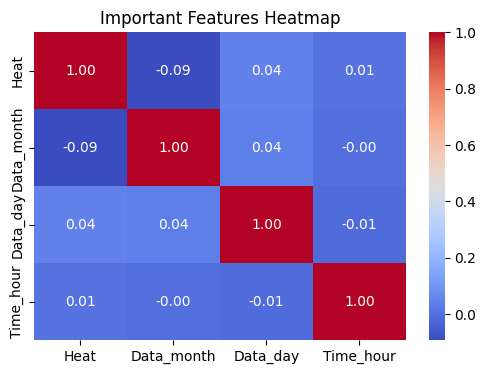

In [8]:
# Histogram
plt.figure(figsize=(8,5))

plt.hist(df_new['Heat'], bins=20, edgecolor='black')

plt.title("Heat Distribution")
plt.xlabel("Heat")
plt.ylabel("Frequency")

plt.show()

#scatterplot
plt.scatter(df['Data_day'], df['Heat'])
plt.title("Heat vs Day")
plt.xlabel("Day")
plt.ylabel("Heat")
plt.show()

#heatmap
import seaborn as sns
important_cols = ['Heat', 'Data_month', 'Data_day', 'Time_hour']

plt.figure(figsize=(6,4))
sns.heatmap(df_new[important_cols].corr(), 
            annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Important Features Heatmap")
plt.show()

7. MODEL TRAINING

In [9]:
y = df_new["Heat"].values.reshape(-1, 1)
x = df_new.drop("Heat", axis=1).values

reg = LinearRegression()
reg.fit(x, y)

print("Model Score:", reg.score(x, y))

Model Score: 0.6290092854370442


8. PREDICTION

In [10]:
prediction_final = reg.predict(df_new1)

Heat = prediction_final.flatten()
idx = list(range(len(Heat)))


c:\Users\verma\Downloads\Weather_heat_prediction_using_ML-weather_heat_prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


9. SAVE OUTPUT

In [15]:


# Create a proper table
df = pd.DataFrame({
    "Index": idx,
    "Predicted Heat": Heat
})

# Show clean output in notebook
display(df)

# Save clean Excel file (optional)
df.to_excel("score.xlsx", index=False)



,Index,Predicted Heat
0,0,183.489094
1,1,231.212714
2,2,203.603468
3,3,217.799101
4,4,222.776774
...,...,...
6532,6532,5.590964
6533,6533,16.059727
6534,6534,20.380290
6535,6535,9.974970


In [17]:
import xlsxwriter

workbook = xlsxwriter.Workbook('score.xlsx')
outsheet = workbook.add_worksheet()

outsheet.write("A1","idx")
outsheet.write("B1","Heat")

for i in range(len(Heat)):
    outsheet.write(i+1, 0, idx[i])
    outsheet.write(i+1, 1, Heat[i])

workbook.close()

print("For detailed Output file is saved as score.xlsx")

For detailed Output file is saved as score.xlsx
